# Bank Load Analysis Report 

## Libries Imported 

In [42]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## Data Check

In [43]:
df = pd.read_excel('financial_loan.xlsx')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## Metadata 

In [44]:
display(df.shape)
df.info()
df.describe()

(38576, 24)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## Total Loan Applications

In [45]:
total_appication_count = df['id'].nunique()

print('Total Number of Applications: ', total_appication_count)

# Month to date loan applications

current_date = pd.Timestamp.today()

mtd_applications = df[(df['issue_date'].dt.month == current_date.month) & (df['issue_date'].dt.day <= current_date.day)]

print('Month to date loan applications: ', mtd_applications['id'].nunique())

Total Number of Applications:  38576
Month to date loan applications:  3184


## Total Funded Amount

In [46]:
total_funded_amount = df['loan_amount'].sum()

print(f'Total funded amount: ${round(total_funded_amount/1000000, 2)}M' )

# month to date funded amount

current_date = pd.Timestamp.today()

mtd_funded_amount = df[(df['issue_date'].dt.month == current_date.month) & (df['issue_date'].dt.day <= current_date.day)]['loan_amount'].sum()

print(f'Month to date funded amount: ${round(mtd_funded_amount/ 1000000, 2)}M')


Total funded amount: $435.76M
Month to date funded amount: $34.16M


## Total Amount Recieved 

In [47]:
total_recieved_amount = df['total_payment'].sum()

print(f'Total recieved amount: ${round(total_recieved_amount/1000000, 2)}M' )

# month to date recieved amount

current_date = pd.Timestamp.today()

mtd_ricieved_amount = df[(df['issue_date'].dt.month == current_date.month) & (df['issue_date'].dt.day <= current_date.day)]['total_payment'].sum()

print(f'Month to date ricieved amount: ${round(mtd_ricieved_amount/ 1000000, 2)}M')


Total recieved amount: $473.07M
Month to date ricieved amount: $36.16M


## Average Interest Rate

In [48]:
avg_int_rate = df['int_rate'].mean() * 100

print(f'Average interest rate: {round(avg_int_rate, 2)}%')

Average interest rate: 12.05%


## Average DTI

In [49]:
avg_dti = df['dti'].mean() * 100

print(f'Average interest rate: {round(avg_dti, 2)}%')

Average interest rate: 13.33%


## Finding Out loans Based on Status

In [50]:
loan_status_df = df.groupby('loan_status').agg(
    number_of_loans = ('id', 'count'), 
    dti = ('dti', 'mean'), 
    interest_rate = ('int_rate', 'mean'), 
    total_loan_amount = ('loan_amount', 'sum'), 
    total_amount_recieved = ('total_payment', 'sum')
)
loan_status_df

,number_of_loans,dti,interest_rate,total_loan_amount,total_amount_recieved
loan_status,,,,,
Charged Off,5333,0.140047,0.138786,65532225,37284763
Current,1098,0.147243,0.150993,18866500,24199914
Fully Paid,32145,0.131674,0.116411,351358350,411586256


## Good loan Analysis

In [51]:
good_loans_count = loan_status_df.loc['Fully Paid', 'number_of_loans'] + loan_status_df.loc['Current', 'number_of_loans']
print(f'Number of good loans: {good_loans_count}')

# Profit on good loans

good_profit = loan_status_df.loc['Fully Paid', 'total_amount_recieved'] + loan_status_df.loc['Current', 'total_amount_recieved'] - loan_status_df.loc['Fully Paid', 'total_loan_amount'] - loan_status_df.loc['Current', 'total_amount_recieved']
print(f'Profit of good loans: {good_profit }')

Number of good loans: 33243
Profit of good loans: 60227906


## Bad loan Analysis

In [52]:
bad_loans_count = loan_status_df.loc['Charged Off', 'number_of_loans'] 
print(f'Number of bad loans: {bad_loans_count}')

# loss on bad loans

loss = loan_status_df.loc['Charged Off', 'total_loan_amount'] - loan_status_df.loc['Charged Off', 'total_amount_recieved'] 
print(f'loss of bad loans: {loss}')

Number of bad loans: 5333
loss of bad loans: 28247462


## Monthly Trend For Total Funded Amount By Issue Date

In [53]:
df['issue_month'] = df['issue_date'].dt.month_name()
df['month_no'] = df['issue_date'].dt.month

monthly_trend = df.groupby(['month_no', 'issue_month'], as_index=  False).agg({
    'loan_amount' : 'sum', 
    'total_payment': 'sum'
})

display(monthly_trend)

,month_no,issue_month,loan_amount,total_payment
0,1,January,25031650,27578836
1,2,February,24647825,27717745
2,3,March,28875700,32264400
3,4,April,29800800,32495533
4,5,May,31738350,33750523
5,6,June,34161475,36164533
6,7,July,35813900,38827220
7,8,August,38149600,42682218
8,9,September,40907725,43983948
9,10,October,44893800,49399567


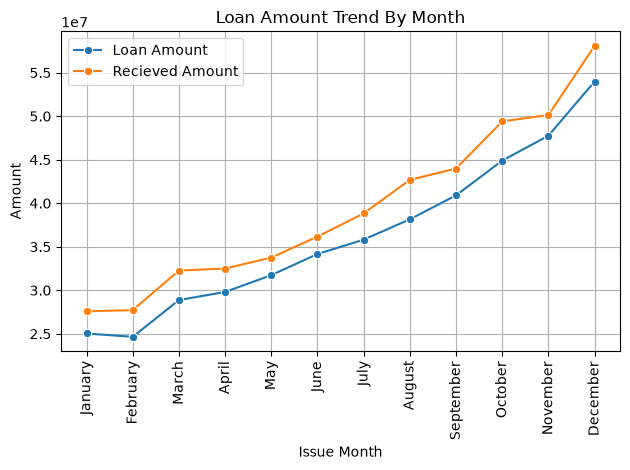

In [58]:
sns.lineplot(monthly_trend, x = 'issue_month',  y = 'loan_amount', marker= 'o', label = 'Loan Amount')
sns.lineplot(monthly_trend, x = 'issue_month',  y = 'total_payment', marker= 'o', label = 'Recieved Amount')

plt.title("Loan Amount Trend By Month")
plt.legend()
plt.xlabel('Issue Month')
plt.xticks(rotation = 90)
plt.yticks()
plt.ylabel('Amount')
plt.grid()
plt.tight_layout()
plt.show()

## Regional Analysis By State

In [ ]:
import matplotlib.pyplot as plt

sizes = [30, 20, 25, 25]
labels = ['A', 'B', 'C', 'D']

# autopct with both value and percentage
plt.pie(sizes, labels=labels, autopct='%.2f%%', )

plt.title("Pie Chart with Values + Percentages")
plt.show()


TypeError: pie() got an unexpected keyword argument 'values'